# DiSENN: Self-Explaining Neural Networks with Disentanglement
---
**Experiment** : Pre Training Beta = 4

## Import libraries

In [49]:
import torch
import torch.nn as nn
from torchvision.utils import make_grid
import numpy as np
from pathlib import Path
from types import SimpleNamespace
import matplotlib.pyplot as plt

%matplotlib inline

In [50]:
from senn.models import *
from senn.models.senn import SENN
from senn.models.parameterizers import ConvParameterizer
from senn.models.conceptizers import ConvConceptizer, VaeConceptizer
from senn.models.aggregators import SumAggregator

## Configuration

In [51]:
plt.style.use('seaborn-v0_8-talk')

In [52]:
config = {
  "model_class": "DiSENN",
  "conceptizer": "VaeConceptizer",
  "pretrain_epochs": 1,
  "pre_beta": 1.0,
  "beta": 4.0,
  "concept_loss": "BVAE_loss",
  "robustness_loss": "mnist_robustness_loss",
  "train": False,
  "image_size": 28,
  "concept_dim": 1,
  "concept_visualization": "None",
  "parameterizer": "ConvParameterizer",
  "cl_sizes": [1, 10, 20],
  "hidden_sizes": [320, 50],
  "num_concepts": 5,
  "num_classes": 10,
  "dropout": 0.5,
  "aggregator": "SumAggregator",
  "device": "cpu",
  "lr": 1e-3,
  "epochs": 10,
  "robust_reg": 1e-2,
  "concept_reg": 1,
  "print_freq": 50,
  "exp_name": "DiSENN_lambda1e-2_c5",
  "dataloader": "fashion_mnist",
  "data_path": "datasets/data/fashion_mnist_data",
  "batch_size" : 128,
  "eval_freq" : 100
}
config = SimpleNamespace(**config)

# DiSENN
DiSENN (Self-Explaining Neural Networks with Disentanglement) is an extension of the Self-Explaining Neural Network proposed by [1]  

DiSENN incorporates a constrained variational inference framework on a 
SENN Concept Encoder to learn disentangled representations of the 
basis concepts as in [2]. The basis concepts are then independently
sensitive to single generative factors leading to better interpretability 
and lesser overlap with other basis concepts. Such a strong constraint 
better fulfills the "diversity" desiderata for basis concepts
in a Self-Explaining Neural Network.


References  
[1] Alvarez Melis, et al.
"Towards Robust Interpretability with Self-Explaining Neural Networks" NIPS 2018  
[2] Irina Higgins, et al. 
”β-VAE: Learning basic visual concepts with a constrained variational framework.” ICLR 2017. 

In [53]:
from senn.models.senn import DiSENN

## Load Data

In [54]:
from senn.datasets.dataloaders import get_dataloader
train_dl, val_dl, test_dl = get_dataloader(config)

## Load Trained Model

In [55]:
conceptizer = eval(config.conceptizer)(**config.__dict__)
parameterizer = eval(config.parameterizer)(**config.__dict__)
aggregator = eval(config.aggregator)(**config.__dict__)

In [56]:
model = DiSENN(conceptizer, parameterizer, aggregator)

In [57]:
checkpoint_path = Path('results')
model_file = checkpoint_path / config.exp_name / "checkpoints" / "best_model.pt" 
checkpoint = torch.load(model_file, config.device, weights_only=False)
print(f"Loading trained model: {model_file}")

Loading trained model: results/DiSENN_lambda1e-2_c5/checkpoints/best_model.pt


In [58]:
model.load_state_dict(checkpoint['model_state'])

<All keys matched successfully>

# Classification

In [59]:
xb, yb = next(iter(val_dl))
y_pred, explanations, x_reconstruct = model(xb)

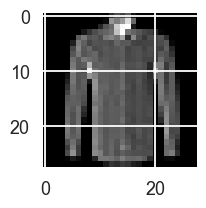

In [60]:
plt.rcParams['figure.figsize'] = (2, 2)
plt.imshow(xb[-1][0], cmap='gray')

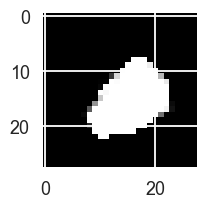

In [61]:
plt.imshow(x_reconstruct[-1][0].detach().numpy(), cmap='gray')

In [62]:
model = model.to(config.device)

In [63]:
accuracy = 0.
model.eval()
with torch.no_grad():
    for i, (x, labels) in enumerate(val_dl):
        x = x.float().to(config.device)
        labels = labels.long().to(config.device)
        y_pred, explanations, x_reconstructed = model(x)
        accuracy += (y_pred.argmax(axis=1) == labels).float().mean().item()
print(f"Test Mean Accuracy: {accuracy / (i+1) * 100:.2f} %")

Test Mean Accuracy: 67.73 %


In [64]:
model = model.to(torch.device('cpu'))

# Explanation

## Generate Prototypes from Disentangled Concepts

In [65]:
(yb==5).nonzero()

tensor([[  6],
        [  8],
        [ 35],
        [ 36],
        [ 55],
        [ 56],
        [ 65],
        [ 84],
        [106],
        [124],
        [125]])

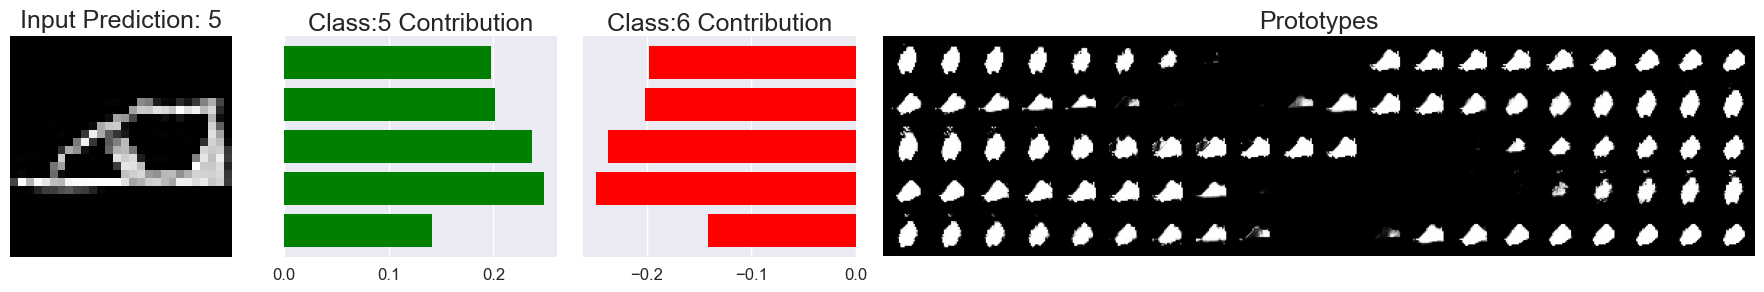

In [83]:
x = xb[6].cpu()
fname = "/digit8a.png"
pred_class = model(x.unsqueeze(0))[0].argmax().item()
contrast_class = (pred_class + 1) % config.num_classes
model.explain(x, contrast_class=contrast_class, traversal_range=0.45,
              gridsize=(1,6), col_span=3, figure_size=(18,3), show=True,
              save_as="results/"+config.exp_name+fname, use_cdf=True)

Possible explanation for "holes"

Because you are artificially drawing a straight line through this space, you might pass through a "dead zone"—a coordinate region where no actual training data exists, and thus the decoder never learned how to reconstruct an object there

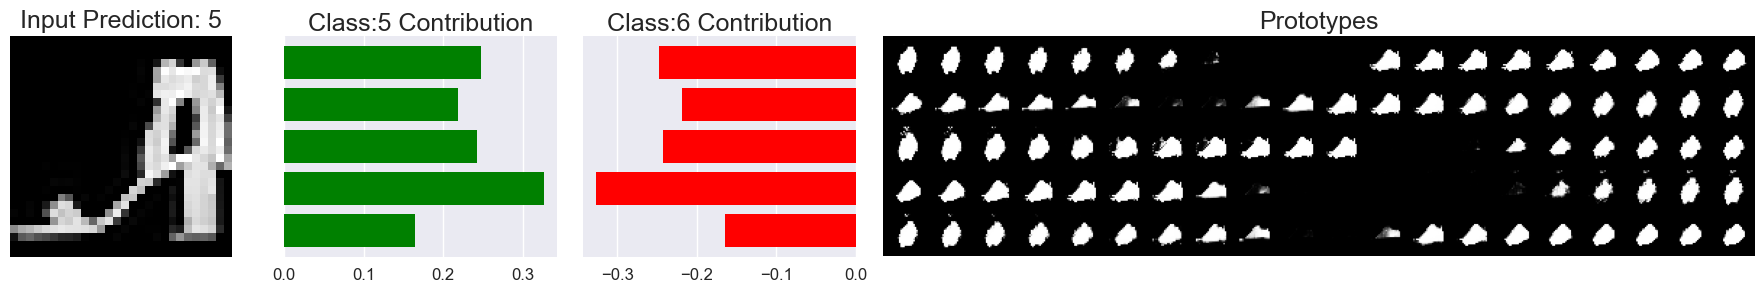

In [67]:
x = xb[8].cpu()
fname = "/digit8b.png"
pred_class = model(x.unsqueeze(0))[0].argmax().item()
contrast_class = (pred_class + 1) % config.num_classes
model.explain(x, contrast_class=contrast_class, traversal_range=0.45,
              gridsize=(1,6), col_span=3, figure_size=(18,3), show=True,
              save_as="results/"+config.exp_name+fname, use_cdf=True)

In [84]:
(yb==6).nonzero()

tensor([[  0],
        [  1],
        [ 14],
        [ 30],
        [ 39],
        [ 49],
        [ 53],
        [ 68],
        [ 69],
        [ 71],
        [ 79],
        [ 88],
        [ 90],
        [103],
        [117],
        [127]])

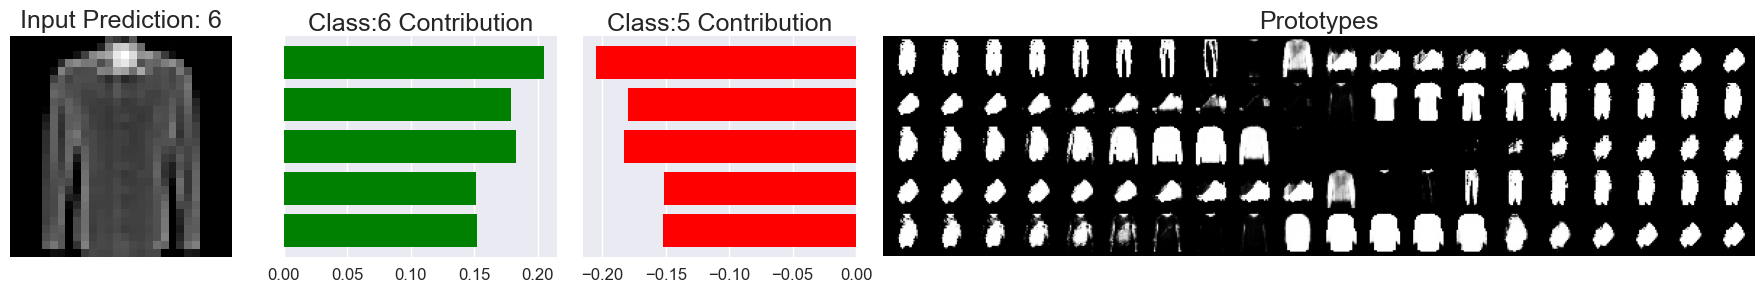

In [85]:
x = xb[49].cpu()
fname = "/digit2a.png"
pred_class = model(x.unsqueeze(0))[0].argmax().item()
contrast_class = 5
model.explain(x, contrast_class=contrast_class, traversal_range=0.45,
              gridsize=(1,6), col_span=3, figure_size=(18,3), show=True,
              save_as="results/"+config.exp_name+fname, use_cdf=True)

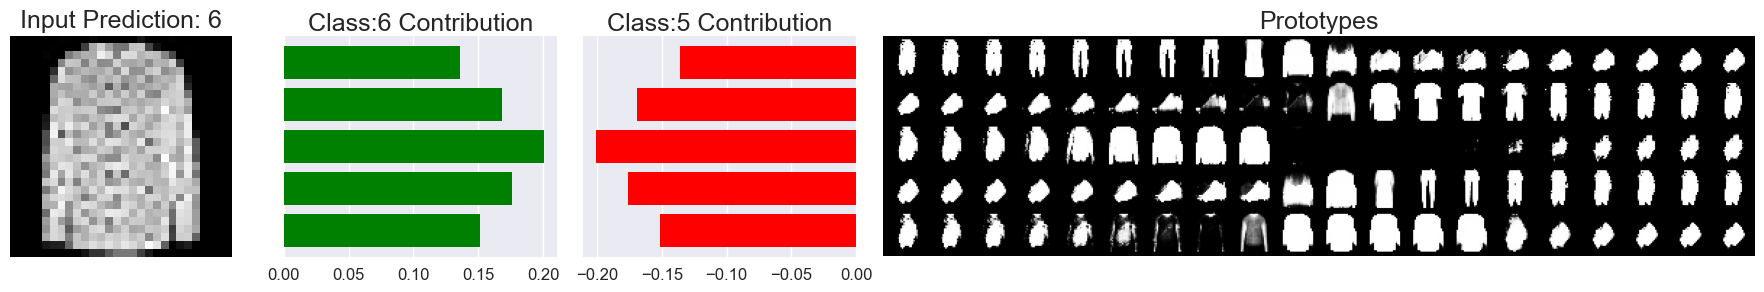

In [86]:
x = xb[53].cpu()
fname = "/digit2b.png"
pred_class = model(x.unsqueeze(0))[0].argmax().item()
contrast_class = 5
model.explain(x, contrast_class=contrast_class, traversal_range=0.45,
              gridsize=(1,6), col_span=3, figure_size=(18,3), show=True,
              save_as="results/"+config.exp_name+fname, use_cdf=True)

Why the protypes look so different for different classes if they come from the same concepts?

When you pass a Sandal into the encoder, it produces a specific latent distribution (x_posterior) in the 5-dimensional concept space.
Sandal Input: Encodes to a "footwear" region of the latent space.
Shirt Input: Encodes to a completely different "apparel" region of the latent space.

The code takes the specific encoding of your input image (xposterior​) as the center point.
It then moves (traverses) a single concept dimension while keeping the other 4 dimensions fixed at the values extracted from your input